In [33]:
import pandas as pd
import numpy as np
import gower
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import warnings


from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore") # Per evitar avisos molests


In [ ]:
# ==============================================================================
# 0. CONFIGURACIÓ INICIAL I DADES
# ==============================================================================
r = 0.2
r_shrink = 0.2

# Carreguem el dataset (assumint que vas guardar el CSV abans de clusteritzar)
# Si tens l'original complet, aquí faries el drop de columnes igual que en R.
dataset = pd.read_csv("../data/dataset_feature_selection_final.csv", dtype={'id': str})

# Definim quines variables entren al clustering (les mateixes que a R)
cols_to_drop = [
    'id', 'source', 'host_id', 'listing_url', 'picture_url', 'host_url', 
    'host_thumbnail_url', 'host_picture_url', 'name', 'description', 
    'neighborhood_overview', 'host_name', 'host_location', 'host_about',
    'host_verifications', 'amenities', 'license', 'latitude', 'longitude',
    'price', 'log_price', 'dies_antiguitat_listing', 'dies_recencia_review', 
    'estimated_revenue_l365d', 'estimated_occupancy_l365d', 'minimum_nights', 
    'maximum_nights', 'number_of_reviews', 'reviews_per_month'
]

# Ens quedem només amb les columnes netes i logarítmiques
data = dataset.drop(columns=cols_to_drop, errors='ignore')

# ------------------------------------------------------------------------------
# SOLUCIÓ PER A LA LLIBRERIA GOWER:
# Convertim tot el que no sigui número a format 'object' estàndard
# ------------------------------------------------------------------------------
for col in data.columns:
    if not pd.api.types.is_numeric_dtype(data[col]):
        data[col] = data[col].astype(object)


In [35]:
# ==============================================================================
# 1. DIVISIÓ DE LA BASE DE DADES (Mostra / No Mostra)
# ==============================================================================
n_mostra = int(np.ceil(0.3 * len(data)))

# Mostreig aleatori (random_state és el set.seed de Python)
data_mostra = data.sample(n=n_mostra, random_state=123)
data_no_mostra = data.drop(data_mostra.index)

Calculant matriu de Gower per a la mostra...


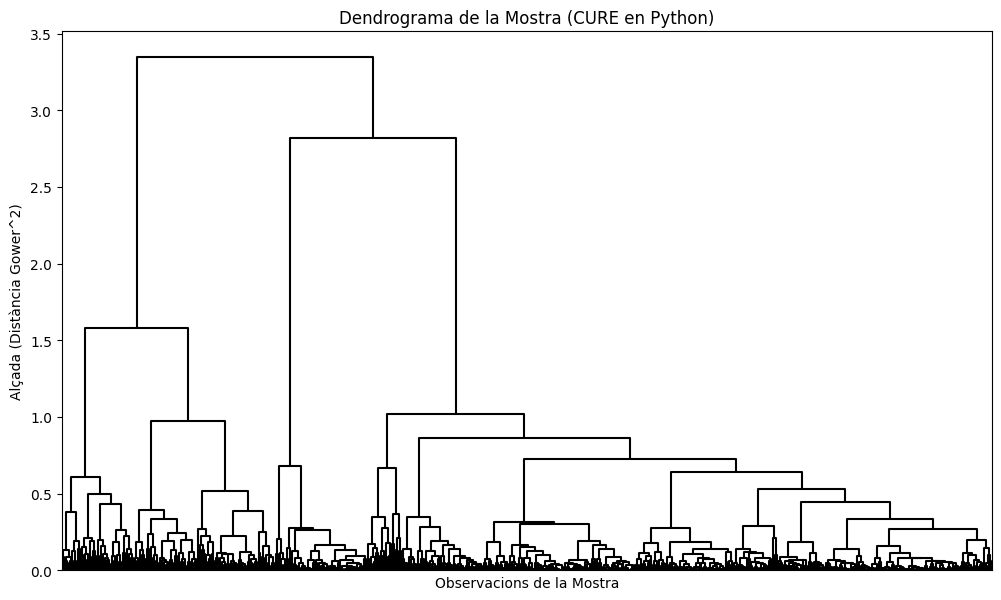

In [36]:
# ==============================================================================
# 2. CLUSTERING JERÀRQUIC DE LA MOSTRA
# ==============================================================================
print("Calculant matriu de Gower per a la mostra...")
dist_matrix = gower.gower_matrix(data_mostra)
dist_matrix_sq = dist_matrix ** 2
condensed_dist = squareform(dist_matrix_sq, checks=False)

# Creem l'arbre
Z = linkage(condensed_dist, method='ward')

# --- DIBUIXEM EL DENDROGRAMA ---
plt.figure(figsize=(12, 7))
plt.title("Dendrograma de la Mostra (CURE en Python)")

# color_threshold=0 i above_threshold_color='black' obliguen a pintar-ho tot de negre
dendrogram(Z, no_labels=True, color_threshold=0, above_threshold_color='black') 

plt.ylabel("Alçada (Distància Gower^2)")
plt.xlabel("Observacions de la Mostra")
plt.show()

In [37]:
# Un cop observat el dendrograma, decidim tallar en k=3
k = 3

# Tallem l'arbre amb la k que hem decidit
data_mostra_clus = data_mostra.copy()
data_mostra_clus['cluster'] = fcluster(Z, k, criterion='maxclust')


In [38]:
# ==============================================================================
# 3. CÀLCUL DELS CENTROIDES MIXTOS
# ==============================================================================
def get_centroide(df):
    centroide = {}
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            centroide[col] = df[col].mean()
        else:
            centroide[col] = df[col].mode()[0] # Agafem la moda
    return pd.DataFrame([centroide])

centroides_llista = []
for i in range(1, k + 1):
    subset = data_mostra_clus[data_mostra_clus['cluster'] == i].drop(columns='cluster')
    cent = get_centroide(subset)
    cent['cluster_id'] = i
    centroides_llista.append(cent)

centroides = pd.concat(centroides_llista, ignore_index=True)

In [39]:
# ==============================================================================
# 4. SELECCIÓ I ENCONGIMENT DE REPRESENTANTS
# ==============================================================================
reps_finals = []

for i in range(1, k + 1):
    subset = data_mostra_clus[data_mostra_clus['cluster'] == i].drop(columns='cluster')
    cent = centroides[centroides['cluster_id'] == i].drop(columns='cluster_id')
    
    # Distància de Gower de cada punt al centroide
    dist_al_cent = gower.gower_matrix(subset, cent).flatten()
    
    # Agafem el 20% més allunyat
    n_rep = max(1, int(np.floor(r * len(subset))))
    
    # Ordenem per distància descendent
    idx_ordenats = np.argsort(dist_al_cent)[::-1]
    reps_orig = subset.iloc[idx_ordenats[:n_rep]].copy()
    
    # Encongiment (Shrinking)
    reps_encongits = reps_orig.copy()
    for col in reps_encongits.columns:
        if pd.api.types.is_numeric_dtype(reps_encongits[col]):
            val_cent = cent[col].values[0]
            reps_encongits[col] = reps_orig[col] + r_shrink * (val_cent - reps_orig[col])
            
    reps_encongits['cluster_rep'] = i
    reps_finals.append(reps_encongits)

representants_finals = pd.concat(reps_finals, ignore_index=True)

In [40]:
# ==============================================================================
# 5. RECALCULAR CENTROIDES*
# ==============================================================================
nous_centroides_llista = []

for i in range(1, k + 1):
    reps_i = representants_finals[representants_finals['cluster_rep'] == i].drop(columns='cluster_rep')
    cent_orig = centroides[centroides['cluster_id'] == i].drop(columns='cluster_id')
    
    # Unim reps + centroide original
    dades_nou_cent = pd.concat([reps_i, cent_orig])
    
    nou_cent = get_centroide(dades_nou_cent)
    nou_cent['cluster_id'] = i
    nous_centroides_llista.append(nou_cent)

nous_centroides = pd.concat(nous_centroides_llista, ignore_index=True)

In [41]:
# ==============================================================================
# 6. ASSIGNACIÓ DE LA NO_MOSTRA
# ==============================================================================
print("Assignant la no_mostra (això pot trigar una mica)...")
dades_nous_cent_net = nous_centroides.drop(columns='cluster_id')

# Calculem distàncies de tota la no_mostra contra els nous centroides de cop
# Retorna matriu N x K
dist_no_mostra = gower.gower_matrix(data_no_mostra, dades_nous_cent_net)

# Assignem al centroide més proper (argmin retorna l'índex 0, 1, 2... li sumem 1 per tenir clúster 1, 2, 3)
data_no_mostra_clus = data_no_mostra.copy()
data_no_mostra_clus['cluster'] = np.argmin(dist_no_mostra, axis=1) + 1


Assignant la no_mostra (això pot trigar una mica)...


In [42]:
# ==============================================================================
# 7. CONSOLIDACIÓ
# ==============================================================================
# Ajuntem mostra i no_mostra
df_clusters = pd.concat([data_mostra_clus, data_no_mostra_clus])

print("\nDistribució final dels clústers:")
print(df_clusters['cluster'].value_counts().sort_index())


Distribució final dels clústers:
cluster
1    2123
2    1129
3    7201
Name: count, dtype: int64


In [43]:
# ==============================================================================
# 8. PERFILAT FINAL EN PYTHON
# ==============================================================================
# Afegim la columna cluster al dataset original (s'alineen per l'índex de Pandas)
df_final_py = dataset.copy()
df_final_py['cluster'] = df_clusters['cluster']

# Fem un agrupament similar a la funció 'summarise' de dplyr
perfil_py = df_final_py.groupby('cluster').agg(
    n=('cluster', 'count'),
    preu_mig=('price', 'mean'),
    ingressos_estimats=('estimated_revenue_l365d', 'mean'),
    disponibilitat_365=('availability_365', 'mean'),
    distancia_centre=('distancia_centre_km', 'mean')
).round(2) # Arrodonim a 2 decimals perquè quedi net

print("Perfil dels Clústers en Python:")
print(perfil_py)

Perfil dels Clústers en Python:
            n  preu_mig  ingressos_estimats  disponibilitat_365  \
cluster                                                           
1        2123    247.98            27554.59              163.56   
2        1129    329.94              469.65              122.12   
3        7201    269.59             7682.52               68.76   

         distancia_centre  
cluster                    
1                    2.42  
2                    2.74  
3                    2.74  


In [ ]:
# Guardem el dataframe final amb les etiquetes del clúster de Python
df_final_py.to_csv("../data/dataset_cure_python.csv", index=False)
print("Arxiu CSV guardat correctament!")

Arxiu CSV guardat correctament!


In [ ]:
import pyreadr

# Ens assegurem de forma explícita que l'ID sigui text net abans de guardar
df_final_py['id'] = df_final_py['id'].astype(str)

# Guardem el dataframe en format RDS natiu d'R
pyreadr.write_rds("../data/dataset_cure_python.rds", df_final_py)

print("Arxiu RDS de Python guardat correctament!")

Arxiu RDS de Python guardat correctament!
